In [322]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

# Proses 1: Import Library

Kode di atas digunakan untuk mengimpor library yang dibutuhkan pada proses pengolahan citra digital.

- `numpy` digunakan untuk operasi matriks dan array pada citra digital.
- `matplotlib.pyplot` digunakan untuk menampilkan gambar, grafik, dan histogram.
- `cv2` (OpenCV) digunakan untuk proses pengolahan citra seperti konversi grayscale, transformasi citra, filtering, dan operasi pengolahan lainnya.

Ketiga library tersebut menjadi dasar utama dalam proses pengolahan citra pada modul ini.

# Proses 2: Membaca dan Menampilkan Citra

Kode di atas digunakan untuk membaca empat citra digital dari folder `Assets` menggunakan fungsi `cv.imread()`. Secara default, OpenCV membaca gambar dalam format warna BGR (Blue, Green, Red), sehingga dilakukan konversi ke format RGB menggunakan fungsi `cv.cvtColor()` agar warna citra sesuai saat ditampilkan menggunakan Matplotlib.

Setelah proses konversi selesai, keempat citra ditampilkan menggunakan `plt.imshhow()` dan `plt.axis('on')` digunakan untuk menampilkan sumbu koordinat gambar.

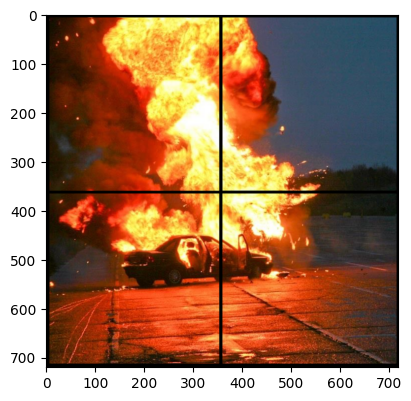

In [323]:
bunga = cv.imread('Assets/Bunga.png')
langit = cv.imread('Assets/Langit.png')
meledak = cv.imread('Assets/Meledak.png')
windut = cv.imread('Assets/Windut.png')

bunga_rgb = cv.cvtColor(bunga, cv.COLOR_BGR2RGB)
langit_rgb = cv.cvtColor(langit, cv.COLOR_BGR2RGB)
meledak_rgb = cv.cvtColor(meledak, cv.COLOR_BGR2RGB)
windut_rgb = cv.cvtColor(windut, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(meledak_rgb)

# Proses 3: Split Citra Menjadi 4 Bagian

Kode di atas digunakan untuk membagi citra menjadi empat bagian menggunakan metode slicing array secara manual. Proses pembagian dilakukan menggunakan fungsi `fungsi_split()` yang dapat melakukan pemotongan citra secara horizontal maupun vertical.

- Mode `'H'` digunakan untuk memotong citra berdasarkan baris (horizontal).
- Mode `'V'` digunakan untuk memotong citra berdasarkan kolom (vertical).

Proses split dilakukan dua tahap:
1. Memotong citra secara horizontal.
2. Hasil potongan kemudian dipotong kembali secara vertical.

Dengan metode tersebut diperoleh empat bagian citra:
- Part 1 → kiri atas
- Part 2 → kanan atas
- Part 3 → kiri bawah
- Part 4 → kanan bawah

Setiap hasil split ditampilkan menggunakan `plt.subplot()` dalam bentuk grid 2×2 agar seluruh bagian citra dapat diamati secara bersamaan.

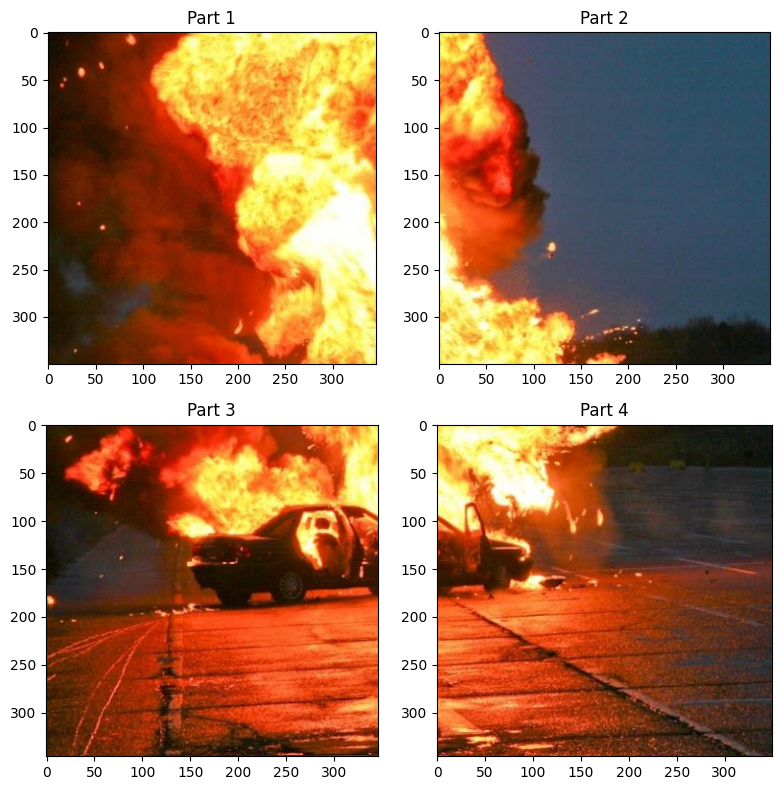

In [324]:
def fungsi_split(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

plt.figure(figsize=(8, 8))

part_1_sementara = fungsi_split(meledak_rgb, 7, 357, mode='H')
part_1 = fungsi_split(part_1_sementara, 7, 353, mode='V')
plt.subplot(2, 2, 1)
plt.imshow(part_1)
plt.title('Part 1')

part_2_sementara = fungsi_split(meledak_rgb, 7, 357, mode='H')
part_2 = fungsi_split(part_2_sementara, 363, 713, mode='V')
plt.subplot(2, 2, 2)
plt.imshow(part_2)
plt.title('Part 2')

part_3_sementara = fungsi_split(meledak_rgb, 367, 713, mode='H')
part_3 = fungsi_split(part_3_sementara, 7, 353, mode='V')
plt.subplot(2, 2, 3)
plt.imshow(part_3)
plt.title('Part 3')

part_4_sementara = fungsi_split(meledak_rgb, 367, 713, mode='H')
part_4 = fungsi_split(part_4_sementara, 363, 713, mode='V')
plt.subplot(2, 2, 4)
plt.imshow(part_4)
plt.title('Part 4')

plt.tight_layout()
plt.show()

# Proses 4: Merge Citra

Kode di atas digunakan untuk menggabungkan beberapa bagian citra menjadi satu gambar utuh menggunakan metode merge secara manual.

Fungsi `merge_image()` mendukung dua jenis penggabungan:
- Horizontal (`'H'`) untuk menggabungkan citra ke arah samping.
- Vertical (`'V'`) untuk menggabungkan citra ke arah bawah.

Proses merge dilakukan dengan membuat canvas baru menggunakan `np.zeros()` sesuai ukuran hasil gabungan. Karena citra yang digunakan merupakan citra RGB, maka canvas dibuat dengan 3 channel warna.

Tahapan merge dilakukan sebagai berikut:
1. Part 1 dan Part 2 digabung secara horizontal menjadi bagian atas.
2. Part 3 dan Part 4 digabung secara horizontal menjadi bagian bawah.
3. Bagian atas dan bawah kemudian digabung secara vertical sehingga menghasilkan citra utuh kembali.

Penggabungan citra dilakukan menggunakan teknik slicing array sehingga setiap bagian citra ditempatkan pada posisi tertentu di dalam canvas hasil merge.

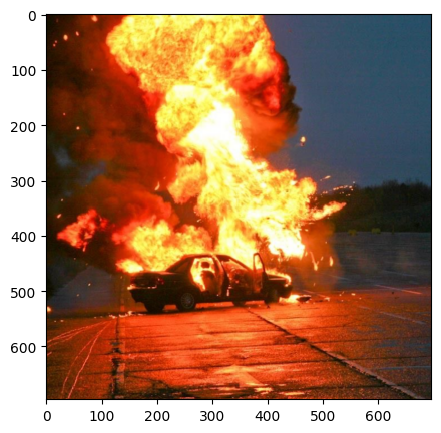

In [325]:
# function merge gambar
def merge_image(citra1, citra2, orientation='H'):
    # merge horizontal
    if orientation == 'H':
        # tinggi canvas
        tinggi = max(citra1.shape[0], citra2.shape[0])
        # lebar canvas
        lebar = citra1.shape[1] + citra2.shape[1]
        # canvas baru RGB
        gabungan = np.zeros((tinggi, lebar, 3),
            dtype=citra1.dtype)
        # simpan citra kiri
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1
        # simpan citra kanan
        gabungan[0:citra2.shape[0],
                 citra1.shape[1]:] = citra2
    # merge vertical
    else:
        # tinggi canvas
        tinggi = citra1.shape[0] + citra2.shape[0]
        # lebar canvas
        lebar = max(citra1.shape[1], citra2.shape[1])
        # canvas baru RGB
        gabungan = np.zeros((tinggi, lebar, 3),
                            dtype=citra1.dtype)
        # simpan citra atas
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1
        # simpan citra bawah
        gabungan[citra1.shape[0]:,
                 0:citra2.shape[1]] = citra2
    return gabungan
# gabung atas
atas = merge_image(part_1, part_2, 'H')
# gabung bawah
bawah = merge_image(part_3, part_4, 'H')
# gabung semua
meledak_merge = merge_image(atas, bawah, 'V')
# tampilkan hasil
plt.figure(figsize=(5,5))
plt.imshow(meledak_merge)
plt.axis('on')
plt.show()

# Proses 5: Konversi Citra RGB ke Grayscale

Kode di atas digunakan untuk mengubah citra RGB menjadi citra grayscale menggunakan fungsi `cv.cvtColor()` dari OpenCV.

Konversi dilakukan menggunakan mode:
```python
cv.COLOR_BGR2GRAY Pada proses ini, setiap pixel warna RGB diubah menjadi satu nilai intensitas abu-abu sehingga citra hanya memiliki satu channel intensitas. Hasil grayscale mempermudah proses pengolahan citra karena operasi selanjutnya hanya dilakukan pada satu nilai intensitas pixel.

Setelah proses konversi selesai, citra grayscale ditampilkan menggunakan plt.imshow() dengan parameter cmap='gray' agar citra ditampilkan dalam skala abu-abu.

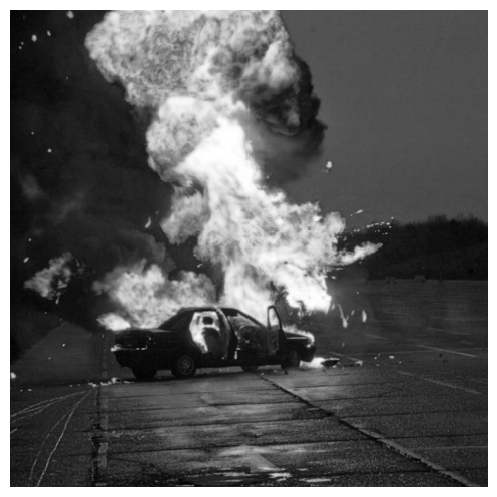

In [326]:
meledak_gray = cv.cvtColor(meledak_merge, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 2)
plt.imshow(meledak_gray, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Proses 6: Histogram Equalization Manual

Kode di atas digunakan untuk melakukan proses histogram equalization secara manual tanpa menggunakan fungsi bawaan OpenCV.

Tahapan proses yang dilakukan adalah:

1. Menghitung histogram citra grayscale.
2. Menghitung cumulative distribution function (CDF).
3. Melakukan normalisasi CDF ke rentang intensitas 0–255.
4. Memetakan setiap pixel lama menjadi pixel baru berdasarkan nilai CDF hasil normalisasi.

Histogram equalization bertujuan untuk meningkatkan kontras citra dengan menyebarkan distribusi intensitas pixel secara lebih merata pada seluruh rentang grayscale.

Proses transformasi intensitas dilakukan menggunakan nilai cumulative histogram sehingga detail citra yang sebelumnya kurang terlihat dapat menjadi lebih jelas.

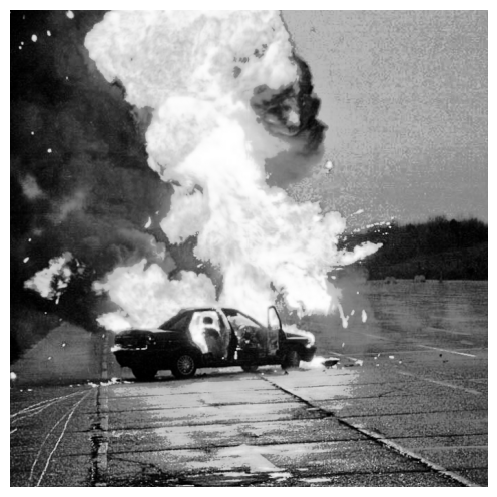

In [327]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]
            
    return hasil

meledak_ekualisasi = ekualisasi(meledak_gray)

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(meledak_ekualisasi, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Proses 7: Histogram Sebelum dan Setelah Ekualisasi

Kode di atas digunakan untuk menghitung dan membandingkan histogram citra sebelum dan setelah proses histogram equalization.

Fungsi `hitung_hist()` digunakan untuk menghitung jumlah kemunculan setiap intensitas pixel secara manual. Histogram disimpan pada array berukuran 256 karena citra grayscale memiliki rentang intensitas dari 0 sampai 255.

Setelah histogram dihitung, hasil ditampilkan menggunakan grafik batang (`plt.bar()`) untuk memperlihatkan distribusi intensitas pixel sebelum dan setelah proses ekualisasi.

- Histogram sebelum ekualisasi menunjukkan distribusi intensitas yang masih terkonsentrasi pada rentang tertentu.
- Histogram setelah ekualisasi menunjukkan distribusi intensitas yang lebih menyebar sehingga kontras citra meningkat.

Perbandingan histogram ini menunjukkan bahwa proses histogram equalization berhasil memperluas penyebaran intensitas pixel pada citra grayscale.

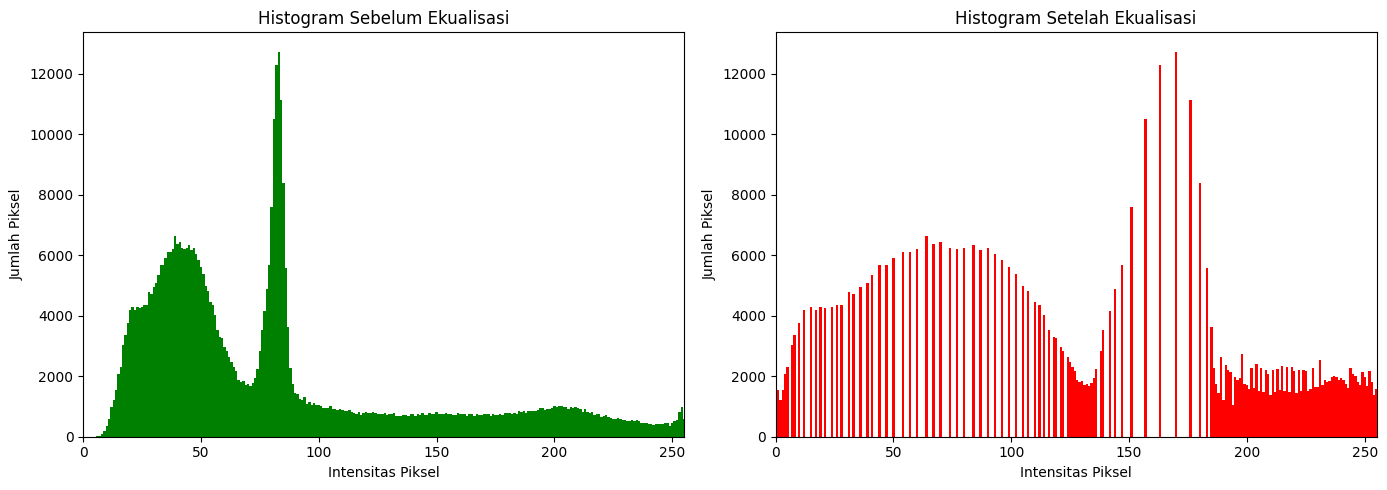

In [341]:
def hitung_hist(citra):
    histogram = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            histogram[citra[i, j]] += 1
    return histogram

hist_sebelum = hitung_hist(meledak_gray)
hist_sesudah = hitung_hist(meledak_ekualisasi)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_sebelum, color='green', width=1.0)
plt.title('Histogram Sebelum Ekualisasi')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_sesudah, color='red', width=1.0)
plt.title('Histogram Setelah Ekualisasi')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

# Proses 8: Perbandingan Histogram Sebelum dan Setelah Ekualisasi

Kode di atas digunakan untuk menampilkan dua histogram dalam satu grafik sehingga distribusi intensitas pixel sebelum dan setelah proses histogram equalization dapat dibandingkan secara langsung.

Histogram pertama ditampilkan menggunakan warna hijau untuk menunjukkan distribusi intensitas citra sebelum ekualisasi, sedangkan histogram kedua menggunakan warna merah untuk menunjukkan distribusi intensitas citra setelah ekualisasi.

Parameter `alpha` digunakan untuk mengatur tingkat transparansi warna sehingga kedua histogram tetap dapat terlihat walaupun saling bertumpuk.

Dari grafik tersebut dapat diamati bahwa histogram hasil ekualisasi memiliki distribusi intensitas yang lebih menyebar dibandingkan histogram awal. Hal ini menunjukkan bahwa proses histogram equalization berhasil meningkatkan kontras citra.

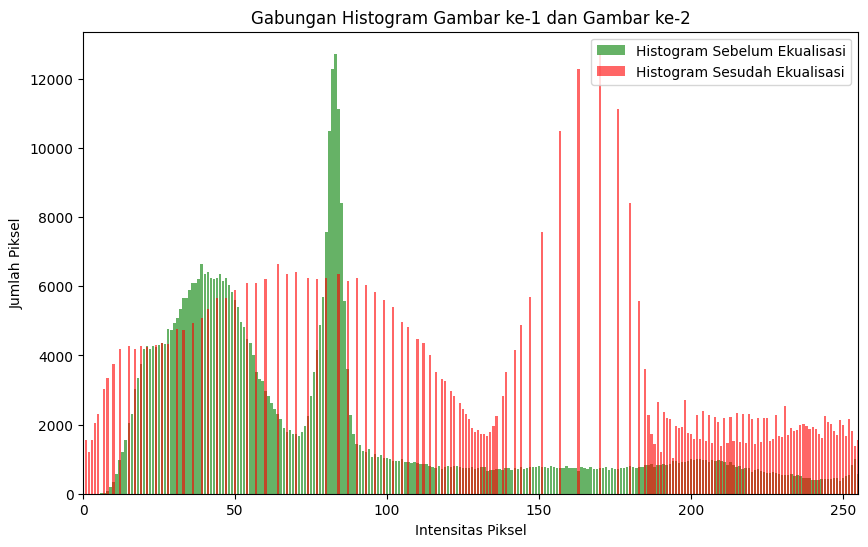

In [330]:
plt.figure(figsize=(10, 6))

plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, label='Histogram Sebelum Ekualisasi', width=0.8)

plt.bar(range(256), hist_sesudah, color='red', alpha=0.6, label='Histogram Sesudah Ekualisasi', width=0.7)

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend(loc='upper right')
plt.xlim([0, 255])

plt.show()

# Proses 9: Konversi Citra RGB ke Grayscale

Kode di atas digunakan untuk mengubah citra RGB menjadi citra grayscale menggunakan fungsi `cv.cvtColor()` dari OpenCV.

Konversi dilakukan menggunakan mode:
```python
cv.COLOR_RGB2GRAY
Pada proses grayscale, setiap pixel warna diubah menjadi satu nilai intensitas abu-abu sehingga citra hanya memiliki satu channel intensitas.

Dua citra grayscale yang dihasilkan kemudian ditampilkan menggunakan plt.subplot() agar kedua gambar dapat dibandingkan secara bersamaan.

Penggunaan citra grayscale mempermudah proses pengolahan citra selanjutnya seperti histogram equalization dan histogram specification karena proses hanya dilakukan pada satu channel intensitas pixel.

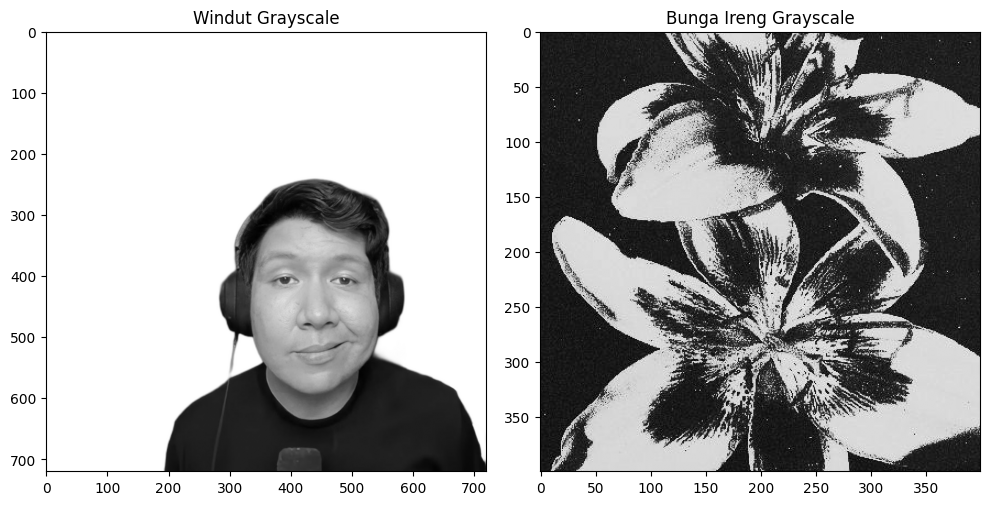

In [331]:
windut_gray = cv.cvtColor(windut_rgb, cv.COLOR_RGB2GRAY)
bunga_gray = cv.cvtColor(bunga_rgb, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(windut_gray, cmap='gray')
plt.title('Windut Grayscale')

plt.subplot(1, 2, 2)
plt.imshow(bunga_gray, cmap='gray')
plt.title('Bunga Ireng Grayscale')

plt.tight_layout()
plt.show()

# Proses 10: Function Histogram Specification

Fungsi `spesifikasi_histogram()` digunakan untuk menyesuaikan distribusi histogram citra asal agar menyerupai distribusi histogram citra target.

Program terlebih dahulu menghitung histogram dan cumulative distribution function (CDF) dari kedua citra. Setelah itu dilakukan proses pencarian mapping intensitas dengan membandingkan nilai CDF citra asal dan citra target.

Mapping histogram yang diperoleh kemudian digunakan untuk mengganti intensitas pixel pada citra asal sehingga dihasilkan citra baru dengan karakteristik pencahayaan dan distribusi intensitas yang lebih menyerupai citra target.


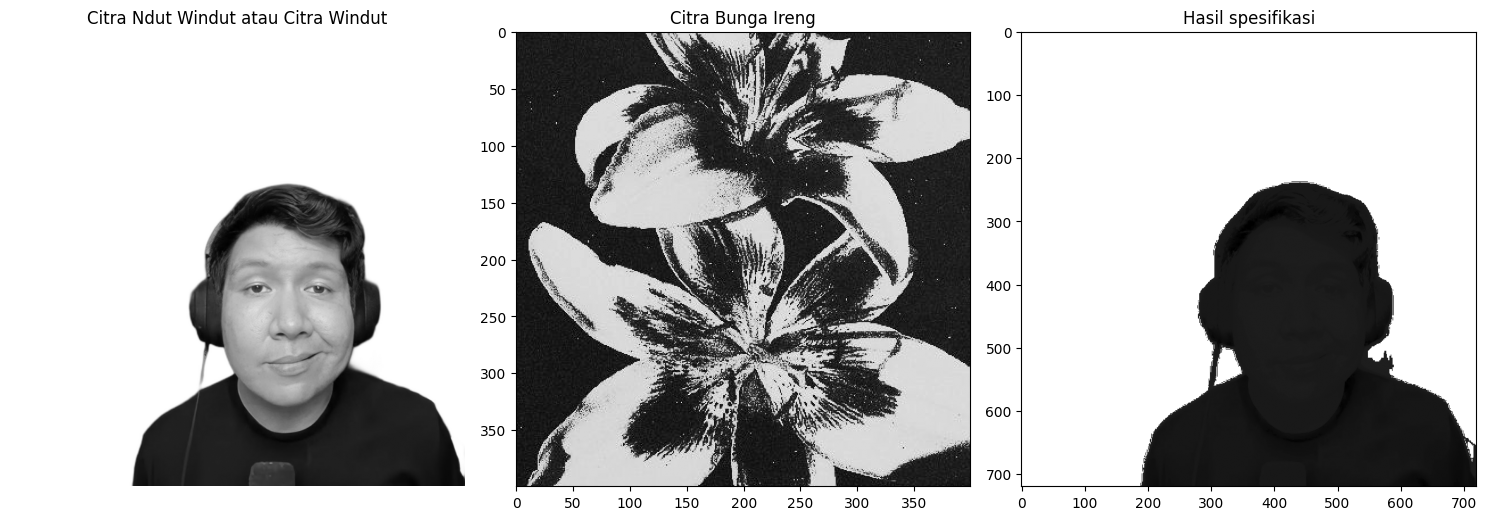

In [332]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1
            
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1
            
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
        
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)
        
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
            
    return hasil

windut_batubara = spesifikasi_histogram(windut_gray, bunga_gray)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(windut_gray, cmap='gray')
plt.title('Citra Ndut Windut atau Citra Windut')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bunga_gray, cmap='gray')
plt.title('Citra Bunga Ireng')

plt.subplot(1, 3, 3)
plt.imshow(windut_batubara, cmap='gray')
plt.title('Hasil spesifikasi')

plt.tight_layout()
plt.show()

# Proses 11: Histogram Hasil Specification
Histogram dihitung menggunakan fungsi `hitung_hist()` yang telah dibuat. Setelah histogram diperoleh, distribusi intensitas pixel ditampilkan menggunakan grafik batang (`plt.bar()`).

Histogram hasil specification menunjukkan bahwa distribusi intensitas citra hasil telah berubah mengikuti karakteristik histogram citra target. Dengan demikian, pencahayaan dan kontras citra hasil menjadi lebih menyerupai citra referensi yang digunakan pada proses histogram specification.

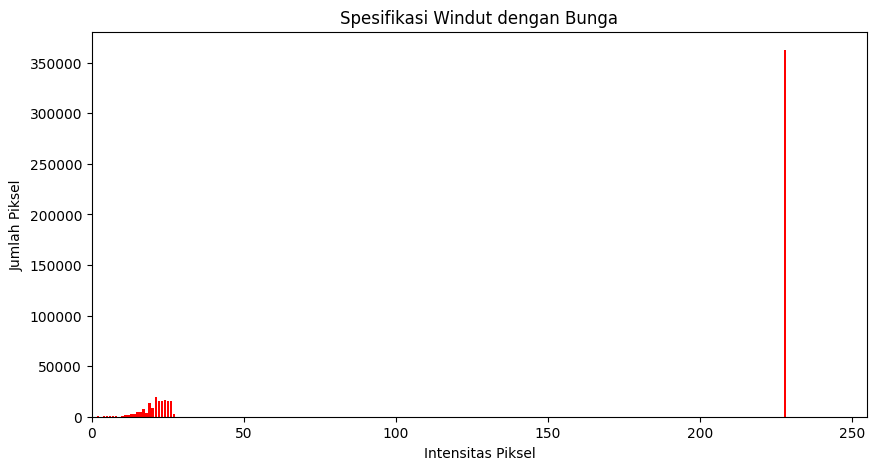

In [333]:
hist_windut_batubara = hitung_hist(windut_batubara)

plt.figure(figsize=(10, 5))

plt.bar(range(256), hist_windut_batubara, color='red', width=0.8)

plt.title('Spesifikasi Windut dengan Bunga')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.show()

# Proses 12: Crop Citra untuk Menyamakan Ukuran

Kode di atas digunakan untuk menyamakan ukuran dua citra sebelum dilakukan proses pengolahan lanjutan.

Ukuran citra `meledak_ekualisasi` dan `windut_batubara` terlebih dahulu diambil menggunakan `.shape`. Setelah itu dicari ukuran terkecil menggunakan fungsi `min()` agar kedua citra dapat dipotong (crop) ke ukuran yang sama.

Proses crop dilakukan menggunakan teknik slicing array:
```python
image[0:min_tinggi, 0:min_lebar]
Metode ini memotong citra berdasarkan tinggi dan lebar minimum sehingga kedua citra memiliki dimensi yang sama tanpa melakukan resize.

Penggunaan crop lebih aman dibanding resize karena nilai intensitas pixel asli tetap dipertahankan dan tidak mengalami interpolasi.

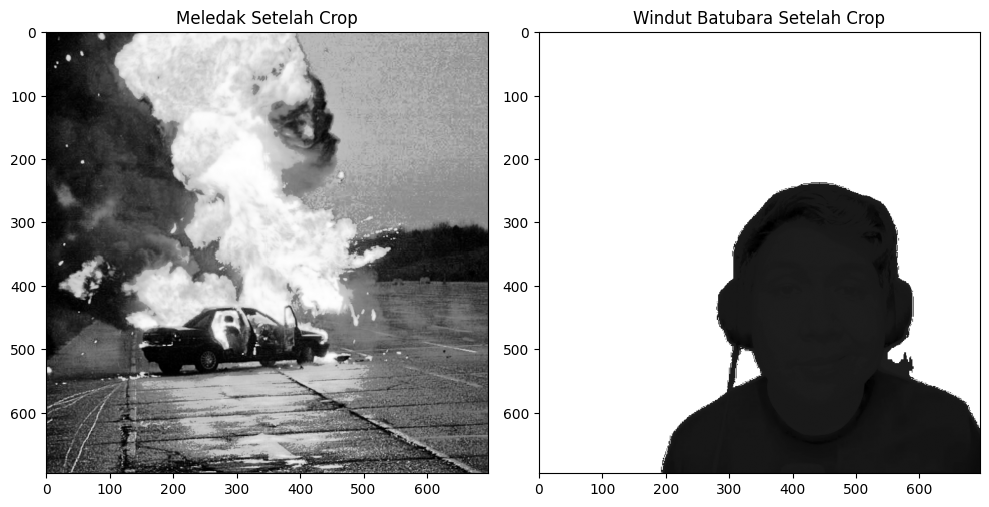

In [334]:
t_meledak, l_meledak = meledak_ekualisasi.shape
t_windut, l_windut = windut_batubara.shape

min_tinggi = min(t_meledak, t_windut)
min_lebar = min(l_meledak, l_windut)

meledak_crop = meledak_ekualisasi[0:min_tinggi, 0:min_lebar]
windut_crop = windut_batubara[0:min_tinggi, 0:min_lebar]

# Kita juga crop windut_gray sebagai patokan (mask) karena background aslinya putih murni
windut_gray_crop = windut_gray[0:min_tinggi, 0:min_lebar] 

# 4. Visualisasi Hasil Crop
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(meledak_crop, cmap='gray')
plt.title('Meledak Setelah Crop')

plt.subplot(1, 2, 2)
plt.imshow(windut_crop, cmap='gray')
plt.title('Windut Batubara Setelah Crop')

plt.tight_layout()
plt.show()

# Proses 13: Masking Manual

Kode di bawah digunakan untuk melakukan proses masking secara manual menggunakan metode pengecekan nilai intensitas pixel.

Pertama dibuat canvas kosong menggunakan `np.zeros()` sebagai tempat penyimpanan hasil masking. Setelah itu dilakukan pemeriksaan setiap pixel menggunakan perulangan bersarang.

Proses masking dilakukan dengan kondisi:
```python
if windut_gray_crop[i, j] > 250
Kondisi tersebut digunakan untuk mendeteksi area background berwarna putih pada citra grayscale. Jika pixel memiliki intensitas lebih besar dari 250, maka pixel dari meledak_crop akan diambil dan disimpan ke hasil masking.

Sebaliknya, jika kondisi tidak terpenuhi maka pixel akan diisi dengan nilai 0 sehingga menjadi warna hitam.

Hasil akhir berupa citra hasil masking yang hanya menampilkan bagian tertentu sesuai area yang memenuhi kondisi intensitas pixel.

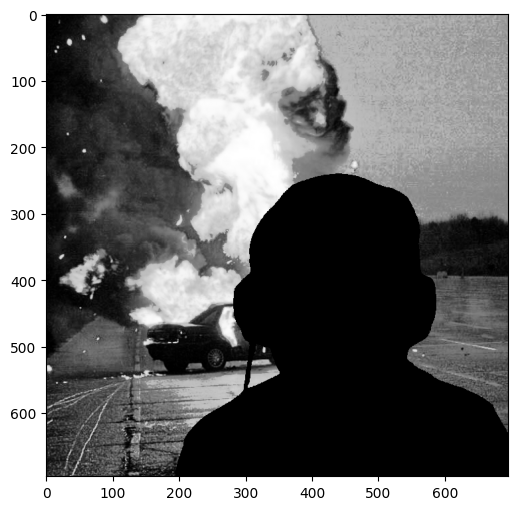

In [335]:
hasil_masking = np.zeros((min_tinggi, min_lebar), dtype=np.uint8)

for i in range(min_tinggi):
    for j in range(min_lebar):
        if windut_gray_crop[i, j] > 250:
            hasil_masking[i, j] = meledak_crop[i, j]
        else:
            hasil_masking[i, j] = 0

plt.figure(figsize=(6, 6))
plt.imshow(hasil_masking, cmap='gray')
plt.show()

# Proses 14: Penggabungan Citra Manual

Kode di bawah digunakan untuk menggabungkan dua citra grayscale menggunakan metode pengecekan intensitas pixel secara manual.

Pertama dibuat canvas kosong menggunakan `np.zeros()` sebagai tempat penyimpanan hasil penggabungan citra.

Selanjutnya dilakukan pemeriksaan setiap pixel menggunakan kondisi:
```python
if windut_gray_crop[i, j] > 240
Jika pixel pada windut_gray_crop memiliki intensitas lebih besar dari 240, maka pixel dari meledak_crop akan digunakan sebagai hasil output. Kondisi ini digunakan untuk mendeteksi area background berwarna putih atau hampir putih.

Sebaliknya, jika kondisi tidak terpenuhi maka pixel asli dari windut_gray_crop akan dipertahankan.

Hasil akhirnya adalah citra gabungan yang mempertahankan objek utama dari citra asli sekaligus mengganti area background tertentu menggunakan citra lain.

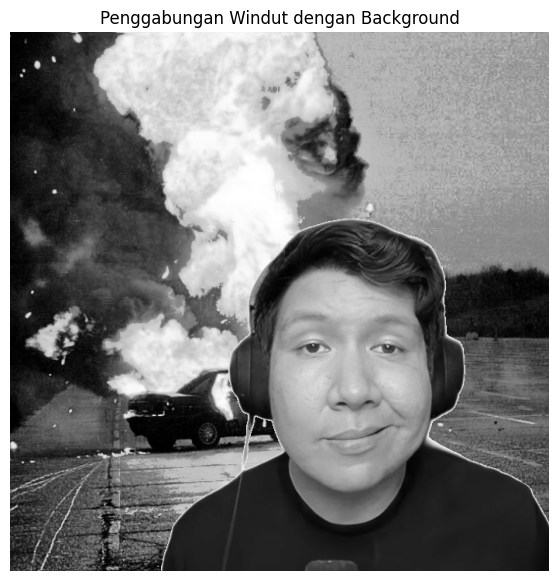

In [336]:
hasil_penggabungan = np.zeros((min_tinggi, min_lebar), dtype=np.uint8)

for i in range(min_tinggi):
    for j in range(min_lebar):
        # Threshold > 240
        if windut_gray_crop[i, j] > 240:
            hasil_penggabungan[i, j] = meledak_crop[i, j]
        else:
            hasil_penggabungan[i, j] = windut_gray_crop[i, j]

plt.figure(figsize=(7, 7))
plt.imshow(hasil_penggabungan, cmap='gray')
plt.title('Penggabungan Windut dengan Background')
plt.axis('off')
plt.show()

# Proses 15: Konversi Citra Langit ke Grayscale

Kode di atas digunakan untuk mengubah citra RGB menjadi citra grayscale menggunakan fungsi `cv.cvtColor()` dari OpenCV.

Konversi dilakukan dengan mode:
```python
cv.COLOR_RGB2GRAY
Pada proses grayscale, tiga channel warna RGB diubah menjadi satu channel intensitas abu-abu sehingga citra lebih sederhana untuk diproses pada tahap pengolahan citra berikutnya.

Citra grayscale hasil konversi kemudian ditampilkan menggunakan plt.imshow() dengan parameter:
cmap='gray'

Penggunaan grayscale mempermudah proses analisis intensitas pixel, histogram, masking, dan operasi pengolahan citra lainnya.

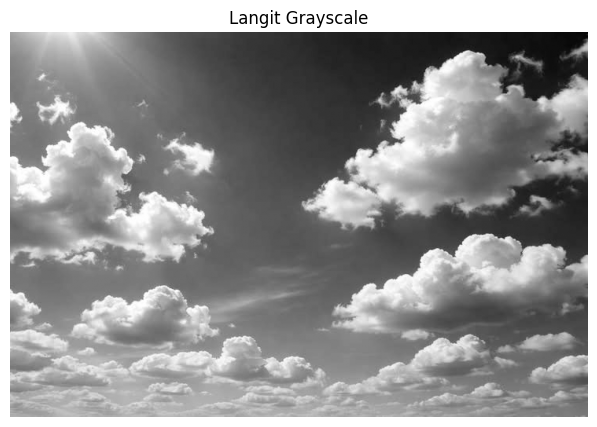

In [337]:
langit_gray = cv.cvtColor(langit_rgb, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(8, 5))
plt.imshow(langit_gray, cmap='gray')
plt.title('Langit Grayscale')
plt.axis('off')
plt.show()

# Proses 16: Penyempurnaan Hasil Menggunakan Histogram Specification

Kode di bawah digunakan untuk melakukan proses histogram specification pada citra hasil penggabungan dengan citra langit grayscale sebagai target histogram.

Pada proses ini:
- `hasil_penggabungan` digunakan sebagai citra asal.
- `langit_gray` digunakan sebagai citra target.

Tujuan proses ini adalah menyesuaikan distribusi intensitas citra hasil penggabungan agar memiliki karakteristik pencahayaan dan kontras yang lebih menyerupai citra langit.

Dengan melakukan histogram specification tahap akhir, hasil citra menjadi lebih halus, lebih seragam, dan memiliki tampilan visual yang lebih menyatu dengan background yang digunakan.

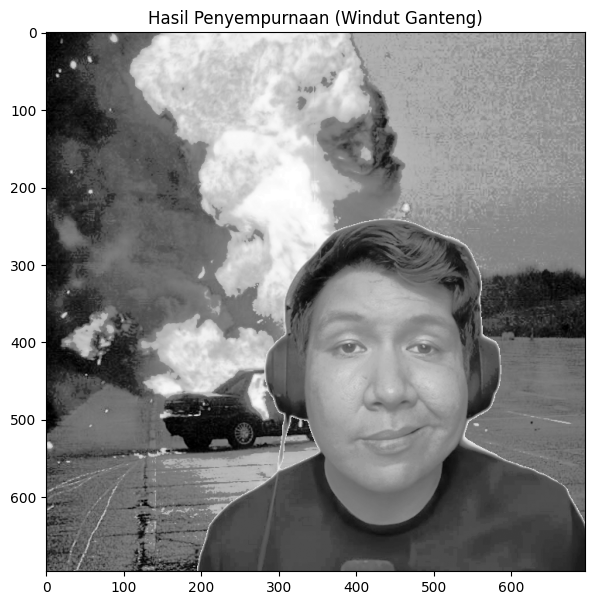

In [338]:
windut_ganteng = spesifikasi_histogram(hasil_penggabungan, langit_gray)

plt.figure(figsize=(7, 7))

plt.imshow(windut_ganteng, cmap='gray')
plt.title('Hasil Penyempurnaan (Windut Ganteng)')
plt.show()

# Proses 17: Histogram Hasil Penyempurnaan

Kode di atas digunakan untuk menampilkan histogram dari citra hasil penyempurnaan akhir (`windut_ganteng`).

Histogram dihitung menggunakan fungsi `hitung_hist()` secara manual untuk memperoleh distribusi intensitas pixel dari citra hasil histogram specification tahap akhir.

Grafik histogram kemudian ditampilkan menggunakan `plt.bar()` sehingga penyebaran intensitas pixel dapat diamati secara visual.

Histogram hasil akhir menunjukkan bahwa distribusi intensitas citra telah mengalami perubahan dan penyesuaian mengikuti karakteristik histogram citra target (`langit_gray`). Proses ini menghasilkan citra dengan pencahayaan dan kontras yang lebih seragam serta tampilan visual yang lebih halus.

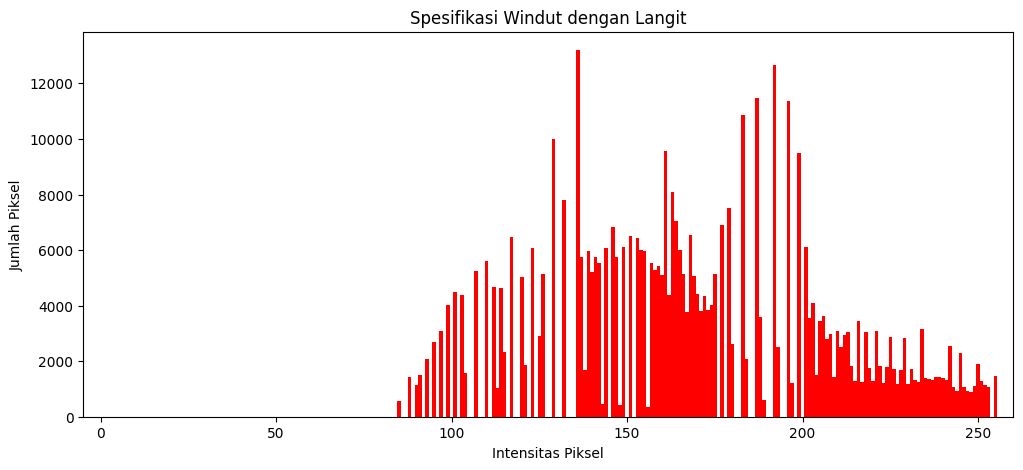

In [339]:
hist_windut_ganteng = hitung_hist(windut_ganteng)

plt.figure(figsize=(12, 5))

plt.bar(range(256), hist_windut_ganteng, color='red', width=1.0)

plt.title('Spesifikasi Windut dengan Langit')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.xlim([-5, 260])

plt.show()

# Proses 18: Penggabungan Citra RGB

Kode di atas digunakan untuk menggabungkan dua citra RGB menggunakan metode masking manual berdasarkan intensitas grayscale.

Citra RGB terlebih dahulu dikonversi ke format BGR menggunakan OpenCV karena proses pengolahan citra dilakukan menggunakan library OpenCV yang secara default menggunakan format warna BGR.

Setelah ukuran kedua citra disamakan menggunakan proses crop, dibuat canvas kosong tiga channel untuk menampung hasil penggabungan.

Proses penggabungan dilakukan dengan memeriksa nilai intensitas pada citra grayscale:
```python
if windut_gray_crop[i, j] > 240
Jika kondisi terpenuhi maka pixel dari citra background digunakan, sedangkan jika tidak maka pixel objek asli dipertahankan.

Hasil akhir ditampilkan menggunakan plt.imshow() tanpa dikonversi kembali ke RGB sehingga menghasilkan perubahan susunan channel warna yang memberikan efek dominasi warna biru pada citra hasil.

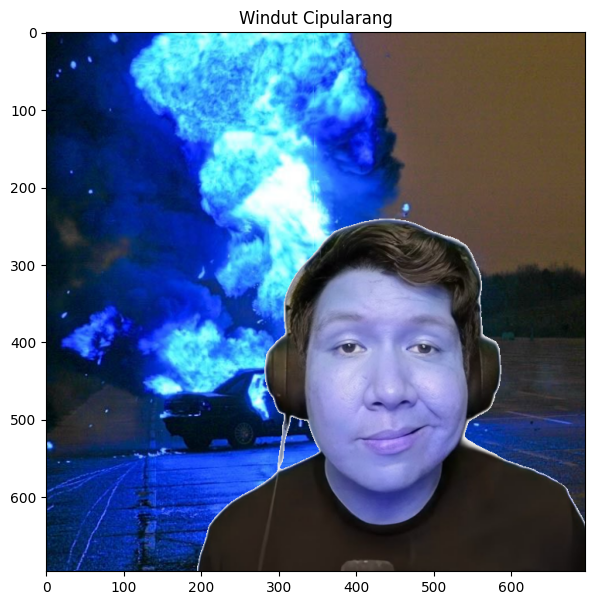

In [340]:
windut_bgr = cv.cvtColor(windut_rgb, cv.COLOR_RGB2BGR)
meledak_bgr_utuh = cv.cvtColor(meledak_merge, cv.COLOR_RGB2BGR)

meledak_bgr_crop = meledak_bgr_utuh[0:min_tinggi, 0:min_lebar]
windut_bgr_crop = windut_bgr[0:min_tinggi, 0:min_lebar]

hasil_cipularang = np.zeros((min_tinggi, min_lebar, 3), dtype=np.uint8)

for i in range(min_tinggi):
    for j in range(min_lebar):
        if windut_gray_crop[i, j] > 240:
            hasil_cipularang[i, j] = meledak_bgr_crop[i, j]
        else:
            hasil_cipularang[i, j] = windut_bgr_crop[i, j]
  
plt.figure(figsize=(7, 7))

plt.imshow(hasil_cipularang)
plt.title('Windut Cipularang')
plt.show()